### Imports and downloading data

In [22]:
import torch
from torchvision import datasets
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import torch.nn as nn

train_data = datasets.FashionMNIST(root='data', train=True, download=True, transform=ToTensor())
test_data = datasets.FashionMNIST(root='data', train=False, download=True, transform=ToTensor())

img1, label1 = train_data[0]
img2, label2 = test_data[1]
img1.shape

torch.Size([1, 28, 28])

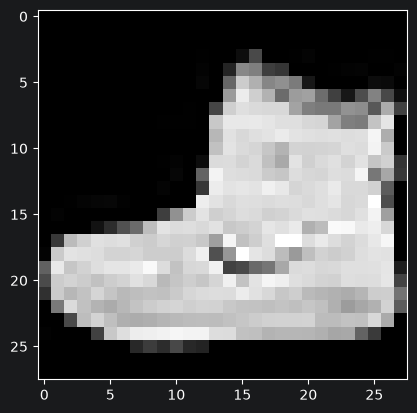

In [23]:
plt.imshow(img1.squeeze(), cmap='gray')

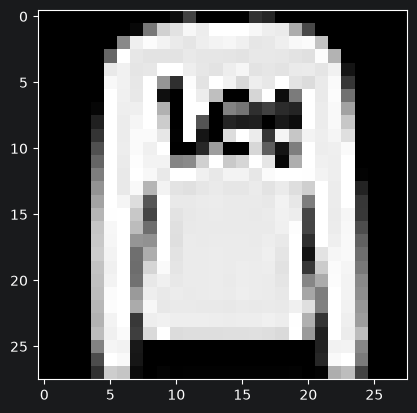

In [24]:
plt.imshow(img2.squeeze(), cmap='gray')

In [25]:
len(train_data)

60000

### Dataloaders

In [26]:
train_dataloader = DataLoader(train_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=False)

### NNModule

In [31]:
class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(784, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

### ForwardPass

In [28]:
X, y = next(iter(train_dataloader))
X.shape

torch.Size([64, 1, 28, 28])

In [29]:
y.shape

torch.Size([64])

In [32]:
model = Model()
output = model(X)
output.shape

torch.Size([64, 10])

In [34]:
torch.isnan(output).any()

tensor(False)